#  Exam Score Forecasting Project

In [45]:
# importing Libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor , RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error , r2_score



In [27]:
# import dataset
df = pd.read_csv("student_dataset_10000_rows.csv")
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  str    
dtypes: float64(1), int64(6), str(1)
memory usage: 625.1 KB


In [29]:
# Statistical information of data
df.describe()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,5.989600,69.88460,6.498500,6.062600,9.988400,64.91100,86.704207
std,3.163589,17.61653,1.709354,3.138163,6.034145,17.50302,15.058383
min,1.000000,40.00000,4.000000,1.000000,0.000000,35.00000,26.670000
25%,3.000000,55.00000,5.000000,3.000000,5.000000,50.00000,76.727500
50%,6.000000,70.00000,6.500000,6.000000,10.000000,65.00000,92.120000
75%,9.000000,85.00000,8.000000,9.000000,15.000000,80.00000,100.000000
max,11.000000,100.00000,9.000000,11.000000,20.000000,95.00000,100.000000


In [30]:
df.isnull().sum()

study_hours              0
attendance               0
sleep_hours              0
internet_usage           0
assignments_completed    0
previous_score           0
exam_score               0
placement_status         0
dtype: int64

In [31]:
X = df.drop(['exam_score' , 'placement_status'], axis=1)
y= df['exam_score']

X_train, X_test, y_train, y_test= train_test_split(X, y, random_state=42, test_size=.20)


In [41]:
# model selection
model = RandomForestRegressor()

# fitting the model
model.fit(X_train , y_train )

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

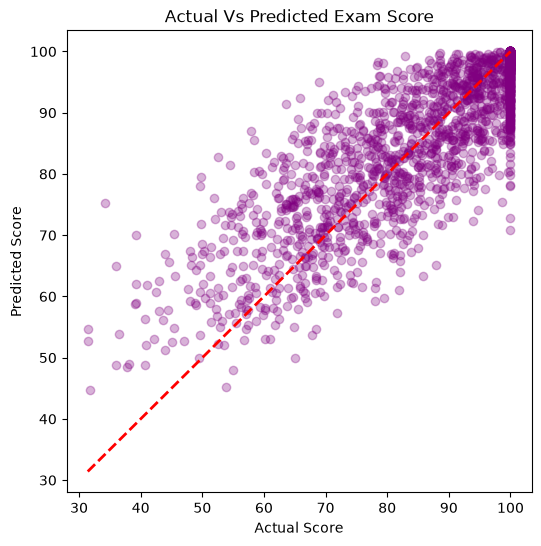

In [42]:
# Predictions vs Actual
y_pred = model.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test , y_pred, alpha=0.3, color='purple')
plt.plot([y_test.min() , y_test.max()] , [y_test.min() , y_test.max()] , 'r--', lw = 2 )
plt.title("Actual Vs Predicted Exam Score")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.show()


In [43]:
# perfomance of the model
print(f"MAE :{mean_squared_error(y_test , y_pred):.2f}")
print(f"RMSE :{root_mean_squared_error(y_test , y_pred):.2f}")
print(f"R2 :{r2_score(y_test , y_pred):.2f}")


MAE :66.36
RMSE :8.15
R2 :0.71


In [46]:
model = GradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)

# Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
plt.title('Feature Impact on Final Exam Score')
plt.xlabel('Importance Weight')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.close()

# Predictions vs Actual
y_pred = model.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Exam Scores')
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.tight_layout()
plt.savefig('predictions_vs_actual.png')
plt.close()

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R2: {r2_score(y_test, y_pred):.2f}")

C:\Users\Tariq\AppData\Local\Temp\ipykernel_5532\4022722530.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=features[indices], palette='viridis')


MAE: 5.96
RMSE: 7.95
R2: 0.72


In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib


# 1. LOAD AND SPLIT DATA
df = pd.read_csv('student_dataset_10000_rows.csv')

# Drop target and unneeded columns for regression
X = df.drop(columns=['exam_score', 'placement_status'])
y = df['exam_score']
\
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. DEFINE PREPROCESSING & MODEL PIPELINE
# List features to ensure deterministic mapping
numerical_features = ['study_hours', 'attendance', 'sleep_hours', 'internet_usage', 'assignments_completed', 'previous_score']

# Step A: Define Preprocessor (Scales data so all features are on a comparable scale)
preprocessor = ColumnTransformer(
                transformers=[
                ('num', StandardScaler(), numerical_features)
                ])

# Step B: Combine Preprocessor and Regressor into a single unified Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])


# 3. TRAIN THE PIPELINE
print("Training the Machine Learning Pipeline...")

pipeline.fit(X_train, y_train)
print("Pipeline trained successfully!\n")


# 4. EVALUATE PERFORMANCE
# The pipeline automatically applies the learned scaling transformations to the test data before predicting
y_pred = pipeline.predict(X_test)

print("--- Pipeline Performance Metrics ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} marks")
print(f"R-squared (R²) Score: {r2_score(y_test, y_pred):.2f}")

# 5. SERIALIZE / SAVE THE PIPELINE
# We save the ENTIRE pipeline object (scaler + model weights combined)
joblib.dump(pipeline, 'student_score_pipeline.pkl')
print("\nPipeline architecture saved as 'student_score_pipeline.pkl'")


# 6. INFERENCE / PRODUCTION TEST
# When predicting on new data, pass raw values directly—the pipeline cleans it inline!
new_student_data = pd.DataFrame([{
    'study_hours': 7,
    'attendance': 92,
    'sleep_hours': 8,
    'internet_usage': 3,
    'assignments_completed': 18,
    'previous_score': 85
}])

# Load the saved pipeline back up
deployed_pipeline = joblib.load('student_score_pipeline.pkl')

# Generate prediction seamlessly
predicted_grade = deployed_pipeline.predict(new_student_data)[0]
print(f"Predicted Final Exam Score: {predicted_grade:.2f}/100")

Training the Machine Learning Pipeline...
Pipeline trained successfully!

--- Pipeline Performance Metrics ---
Mean Absolute Error (MAE): 5.96 marks
R-squared (R²) Score: 0.72

Pipeline architecture saved as 'student_score_pipeline.pkl'
Predicted Final Exam Score: 104.95/100
